In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/mart_ticket_modeling.csv")

print(df.shape)
df.head()

(10000, 52)


,ticket_id,booking_id,issue_category,contact_channel,priority_initial,guest_id,host_id,listing_id,nights,days_until_checkin_at_ticket,...,senior_agent_routing,rebooking_coupon_offered,repeat_contact_probability,repeat_contact_7d,escalation_probability,escalated,resolution_hours,csat_score,poor_csat,long_resolution
0,T000000,B000000,payment_problem,email,high,G00882,H00938,L02865,9,12,...,1,0,0.088,0,0.089,0,4.98,5,0,0
1,T000001,B000001,policy_question,chat,medium,G01659,H00095,L00570,2,2,...,1,0,0.223,0,0.114,0,4.80,5,0,0
2,T000002,B000002,refund_request,chat,medium,G03280,H00088,L01038,8,4,...,1,0,0.265,0,0.122,0,13.65,5,0,0
3,T000003,B000003,refund_request,phone,low,G03348,H01238,L00180,5,7,...,0,1,0.492,1,0.328,0,22.14,4,0,0
4,T000004,B000004,policy_question,chat,low,G03456,H00039,L00952,5,28,...,0,0,0.338,0,0.139,0,2.02,4,0,0


In [2]:
target = "repeat_contact_7d"

df[target].value_counts(normalize=True)

repeat_contact_7d
0    0.6285
1    0.3715
Name: proportion, dtype: float64

In [3]:
target = "repeat_contact_7d"

drop_cols = [
    "ticket_id",
    "booking_id",
    "guest_id",
    "host_id",
    "listing_id",

    # targets / future outcomes
    "repeat_contact_7d",
    "escalated",
    "poor_csat",
    "long_resolution",
    "csat_score",
    "resolution_hours",

    # synthetic probabilities, not available in real life
    "repeat_contact_probability",
    "escalation_probability",
]

drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols)
y = df[target]

print(X.shape)
print(y.mean())

(10000, 39)
0.3715


In [4]:
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['issue_category', 'contact_channel', 'priority_initial', 'booking_status', 'cancelled_by', 'market', 'property_type', 'cancellation_policy']
Numeric columns: ['nights', 'days_until_checkin_at_ticket', 'total_booking_value', 'guest_account_age_days', 'guest_past_bookings_count', 'guest_past_support_tickets_12m', 'guest_past_refund_requests_12m', 'guest_lifetime_booking_value', 'guest_id_verified', 'host_superhost', 'host_response_rate', 'host_cancellation_rate_12m', 'host_avg_response_time_minutes', 'host_past_guest_complaints_12m', 'host_avg_rating', 'nightly_price', 'listing_review_score', 'listing_cleanliness_score', 'listing_accuracy_score', 'listing_review_count', 'instant_book_enabled', 'same_week_checkin_flag', 'strict_policy_flag', 'host_cancelled_booking_flag', 'high_value_booking_flag', 'sentiment_score', 'urgency_score', 'time_to_first_agent_response_minutes', 'message_count_first_30min', 'senior_agent_routing', 'rebooking_coupon_offered']


/var/folders/78/y2_1gdzn2kd4k_m309p88yxw0000gn/T/ipykernel_81354/908418193.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(7500, 39) (2500, 39)
0.37146666666666667 0.3716


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [7]:
from sklearn.linear_model import LogisticRegression

log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

log_reg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['issue_category','contact_channel','priority_initial',..., 'message_count_first_30min','senior_agent_routing', 'rebooking_coupon_offered']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (de

In [8]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

y_pred = log_reg_model.predict(X_test)
y_prob = log_reg_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))
print()
print(classification_report(y_test, y_pred))
print()
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.7186
PR-AUC: 0.6076

              precision    recall  f1-score   support

           0       0.77      0.70      0.73      1571
           1       0.56      0.64      0.60       929

    accuracy                           0.68      2500
   macro avg       0.66      0.67      0.67      2500
weighted avg       0.69      0.68      0.68      2500


[[1103  468]
 [ 334  595]]


In [9]:
eval_df = X_test.copy()
eval_df["actual_repeat_contact"] = y_test.values
eval_df["predicted_repeat_probability"] = y_prob

eval_df["risk_decile"] = pd.qcut(
    eval_df["predicted_repeat_probability"],
    q=10,
    labels=False,
    duplicates="drop"
)

decile_summary = (
    eval_df.groupby("risk_decile")
    .agg(
        tickets=("actual_repeat_contact", "count"),
        avg_predicted_risk=("predicted_repeat_probability", "mean"),
        actual_repeat_rate=("actual_repeat_contact", "mean")
    )
    .sort_index(ascending=False)
)

decile_summary

,tickets,avg_predicted_risk,actual_repeat_rate
risk_decile,,,
9,250,0.831552,0.724
8,250,0.712897,0.600
7,250,0.623857,0.524
6,250,0.550990,0.460
5,250,0.485401,0.296
4,250,0.430354,0.268
3,250,0.378611,0.272
2,250,0.334182,0.224
1,250,0.285464,0.180


In [10]:
decile_display = decile_summary.copy()
decile_display["avg_predicted_risk"] = (decile_display["avg_predicted_risk"] * 100).round(2).astype(str) + "%"
decile_display["actual_repeat_rate"] = (decile_display["actual_repeat_rate"] * 100).round(2).astype(str) + "%"

decile_display

,tickets,avg_predicted_risk,actual_repeat_rate
risk_decile,,,
9,250,83.16%,72.4%
8,250,71.29%,60.0%
7,250,62.39%,52.4%
6,250,55.1%,46.0%
5,250,48.54%,29.6%
4,250,43.04%,26.8%
3,250,37.86%,27.2%
2,250,33.42%,22.4%
1,250,28.55%,18.0%


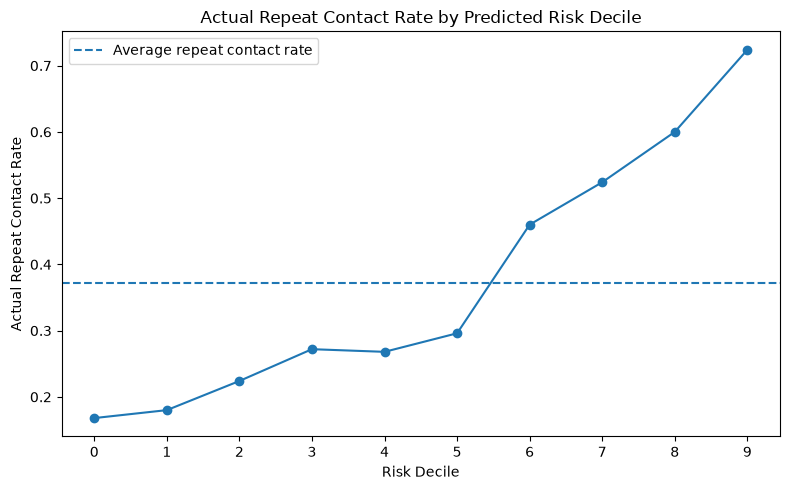

In [11]:
import matplotlib.pyplot as plt

plot_data = decile_summary.sort_index()

plt.figure(figsize=(8, 5))
plt.plot(plot_data.index.astype(str), plot_data["actual_repeat_rate"], marker="o")
plt.axhline(y_test.mean(), linestyle="--", label="Average repeat contact rate")
plt.title("Actual Repeat Contact Rate by Predicted Risk Decile")
plt.xlabel("Risk Decile")
plt.ylabel("Actual Repeat Contact Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
feature_names_num = numeric_cols

onehot = (
    log_reg_model
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
)

feature_names_cat = onehot.get_feature_names_out(categorical_cols).tolist()

feature_names = feature_names_num + feature_names_cat

coef = log_reg_model.named_steps["model"].coef_[0]

importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
})

importance["abs_coefficient"] = importance["coefficient"].abs()

importance.sort_values("abs_coefficient", ascending=False).head(25)

,feature,coefficient,abs_coefficient
37,issue_category_safety_issue,0.816236,0.816236
32,issue_category_host_cancellation,0.424285,0.424285
34,issue_category_payment_problem,-0.333373,0.333373
25,sentiment_score,-0.323567,0.323567
26,urgency_score,0.307649,0.307649
35,issue_category_policy_question,-0.274932,0.274932
29,senior_agent_routing,-0.240009,0.240009
36,issue_category_refund_request,-0.236782,0.236782
31,issue_category_checkin_problem,-0.206895,0.206895
33,issue_category_listing_not_as_described,-0.176125,0.176125


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=30,
            random_state=42,
            class_weight="balanced_subsample",
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))
print("Random Forest PR-AUC:", round(average_precision_score(y_test, rf_prob), 4))

Random Forest ROC-AUC: 0.7165
Random Forest PR-AUC: 0.6045


In [14]:
model_comparison = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "roc_auc": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ],
    "pr_auc": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, rf_prob)
    ]
})

model_comparison

,model,roc_auc,pr_auc
0,Logistic Regression,0.718609,0.607631
1,Random Forest,0.716515,0.604529


In [15]:
print("Step 3 Model Summary")
print("-" * 60)
print(f"Target: {target}")
print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Test repeat contact rate: {y_test.mean():.2%}")
print()
print("Logistic Regression")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, y_prob):.4f}")
print()
print("Random Forest")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, rf_prob):.4f}")
print()
print("Business interpretation:")
print(
    "The model estimates which tickets are likely to generate repeat contact. "
    "This can be used to prioritize proactive support, senior-agent routing, "
    "or specialist workflows for the highest-risk tickets."
)

Step 3 Model Summary
------------------------------------------------------------
Target: repeat_contact_7d
Train rows: 7,500
Test rows: 2,500
Test repeat contact rate: 37.16%

Logistic Regression
ROC-AUC: 0.7186
PR-AUC: 0.6076

Random Forest
ROC-AUC: 0.7165
PR-AUC: 0.6045

Business interpretation:
The model estimates which tickets are likely to generate repeat contact. This can be used to prioritize proactive support, senior-agent routing, or specialist workflows for the highest-risk tickets.


I first built a repeat-contact prediction model because repeat contact is a strong signal that the first support resolution failed. I used only features available at ticket creation or early handling, such as issue type, contact channel, priority, booking value, days until check-in, guest history, host reliability, listing quality, sentiment, urgency, and first response time.

I started with logistic regression as an explainable baseline, then compared it with a Random Forest to capture non-linear interactions. I evaluated the model using ROC-AUC, PR-AUC, and especially top-decile lift because the business would likely act only on the highest-risk tickets.

The goal was not just model accuracy. The goal was to identify the top-risk support cases that should receive proactive intervention before they become repeat contacts or escalations.